In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the real velocity CSV file
real_velocity_df = pd.read_csv('real_velocity.csv')  # Replace with your real velocity CSV file

# Initialize a DataFrame to store accuracy results
accuracy_df = pd.DataFrame(columns=['Parameters', 'Accuracy'])

# Function to calculate accuracy between real and generated velocities
def calculate_accuracy(real, generated):
    return 1 - abs(real - generated) / real

# List of generated velocity CSV files
generated_files = ['velocity generated/df_lk.csv', 'velocity generated/df_corners_1.csv', 'velocity generated/df_corners_2.csv',
                    'velocity generated/df_corners_3.csv', 'velocity generated/df_quality_1.csv', 'velocity generated/df_quality_2.csv']

# Loop through each generated velocity file
for generated_file in generated_files:
    # Load the generated velocity CSV file
    generated_df = pd.read_csv(generated_file)

    # Extract the column name for velocity ('v')
    velocity_column_name = [col for col in generated_df.columns if 'v' in col.lower()][0]

    # Merge real and generated DataFrames based on the common index (assuming the DataFrames have the same length)
    merged_df = pd.merge(real_velocity_df, generated_df, left_index=True, right_index=True)

    # Calculate accuracy for each row and average accuracy for the entire set
    merged_df['Accuracy'] = calculate_accuracy(merged_df['velocity'], merged_df[velocity_column_name])

    # Calculate average accuracy for the entire set of parameters
    average_accuracy = merged_df['Accuracy'].mean()

    # Append the results to the accuracy DataFrame
    accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)

# Save the accuracy results to a new CSV file
accuracy_df.to_csv('accuracy_results.csv', index=False)

# Display the accuracy results
print(accuracy_df)


                            Parameters  Accuracy
0         velocity generated/df_lk.csv  0.276087
1  velocity generated/df_corners_1.csv  0.271146
2  velocity generated/df_corners_2.csv  0.273760
3  velocity generated/df_corners_3.csv  0.273407
4  velocity generated/df_quality_1.csv  0.152199
5  velocity generated/df_quality_2.csv  0.159059


C:\Users\DELL\AppData\Local\Temp\ipykernel_1800\626588881.py:35: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_1800\626588881.py:35: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_1800\626588881.py:35: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_1800\626588881.

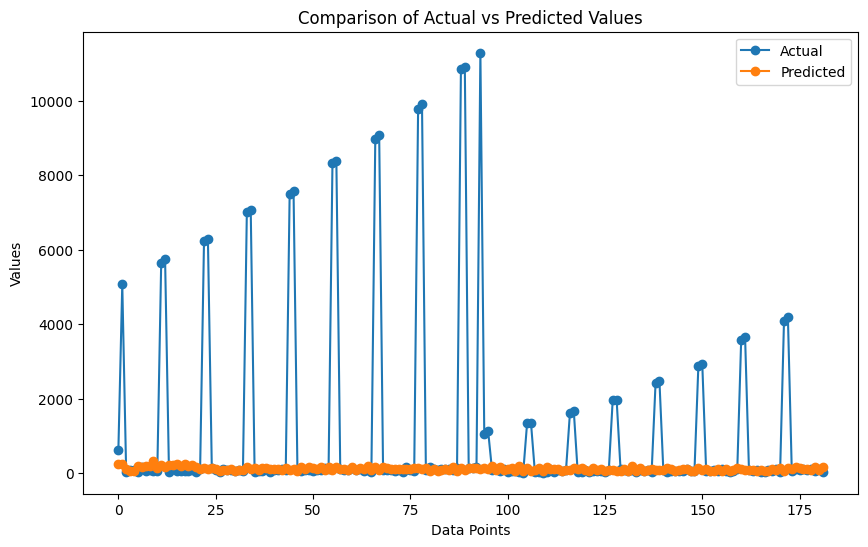

In [15]:
df = pd.read_csv('velocity generated/df_lk.csv')  # Replace with your real velocity CSV file


# Plotting a line chart with a larger figure
index = np.arange(len(df))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, real_velocity_df['velocity'], label='Actual', marker='o')
plt.plot(index, df['v_lk'], label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values')

# Add legend
plt.legend()

# Show the plot
plt.show()
